# Fase 0: fundamentos de redes neurais com NumPy
**Objetivo:** Compreender o funcionamento dos algoritmos fundamentais de redes neurais.

**Conceitos-chave:** regressão, gradiente descendente, neurônio, função de ativação, *backpropagation*.

### Sumário
*Etapa 0.1: Gradiente Descendente*

*Etapa 0.2: MLP do zero*

*Etapa 0.3: *Backpropagation**

*Etapa 0.4: *Autograd* simples*

**Mini-projeto 0: A curva de luz de uma supernova Ia**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Mini-projeto 0 — A curva de luz de uma supernova Ia

## 1. Descrição do problema
Nosso objetivo é prever qual o fluxo de luminosidade no pico da supernova e em quantos dias após o início da supernova ele ocorre. Para isso, usaremos dados reais contidos no arquivo `supernova1.txt`.

Esse arquivo contém várias informações, mas estamos interessados nas linhas que contêm `OBS`, mais especificamente, nas colunas `MJD` (medida de tempo astrônomica), `FLT` (banda utilizada na observação, queremos a que possui mais observações), `FLUXCAL` (fluxo de luminosidade) e `FLUXERR` (erro do fluxo dee luminosidade). Vamos extrair os dados.

In [2]:
mjd, flux, flux_err = [], [], [] # Criando as listas que armazenarão os dados

with open('supernova1.txt', 'r') as f: # Abrindo o arquivo
    for line in f: # Percorrendo o arquivo linha a linha
        if line.startswith('OBS:'): # Caso a linha comece com OBS:
            parts = line.split() # Separo os termos separados por espaço em cada linha
            banda = parts[2] # Leio a banda daquela linha
            if banda == 'b':  # Escolho a banda com mais observações
                mjd.append(float(parts[1])) # Leio os dados de interesse
                flux.append(float(parts[6]))
                flux_err.append(float(parts[7]))

# MJD armazena o número de dias passados desde uma data específica,
# como estamos interessados no intervalo desde o início da supernova:
for i in range(1, len(mjd)):
    mjd[i] = mjd[i] - mjd[0]
mjd[0] = 0

# Transformo as listas em arrays numpy
np_mjd = np.array(mjd).reshape(-1, 1)
np_flux = np.array(flux).reshape(-1, 1)
np_flux_err = np.array(flux_err).reshape(-1, 1)

Vamos visualizar os dados.

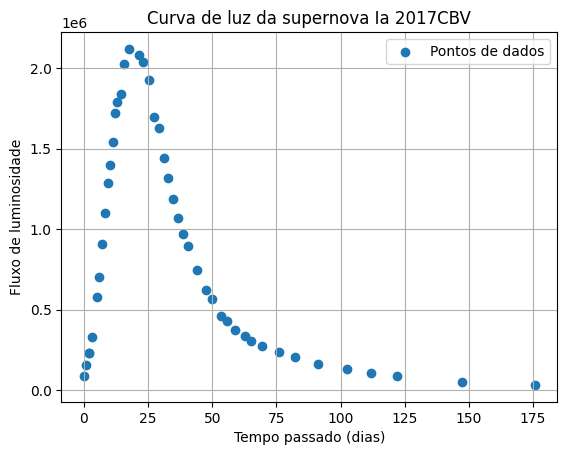

In [3]:
plt.scatter(mjd, flux, label='Pontos de dados')
plt.xlabel('Tempo passado (dias)')
plt.ylabel('Fluxo de luminosidade')
plt.title('Curva de luz da supernova Ia 2017CBV')
plt.legend()
plt.grid()
plt.show()

Vamos trazer nossas classes da etapa 0.3 adicionando o método `.treinamento()`, responsável por executar as iterações. Também usaremos a função de perda definida pelo $\chi ^{2}$ , definida como
$$
L = \sum_{i=1}^{N} \left( \frac{y_{i} - \hat{y}_{i}}{\sigma _{i}}\right)^{2},
$$
em que $sigma_{i}$ é a incerta do dado $y_{i}$. Usaremos essa função de perda justamente porque nossos dados possuem incertezas.

In [24]:
class Camada:
    ''' Define uma camada de neurônios.
    
    Atributos:
        n_entrada: número de entradas recebidas por cada neurônio da camada.
        n_saida: número de neurônios desta camada.        
    '''
    # Inicialização de uma camada
    def __init__(self, n_entrada, n_saida):
        self.n_entrada = n_entrada
        self.n_saida = n_saida

        self.pesos = np.random.randn(n_entrada, n_saida) # Gera a matriz de pesos cuja dimensão é n_entrada x n_saida
        self.bias = np.random.randn(1, n_saida) # Gera a matriz de bias cuja dimensão é 1 x n_saida

    # Vamos definir um método `forward` para executar o forward propagation
    def forward(self, entrada):
        ''' Executa o foward propagation pela camada.
        Parâmetros:
            entrada: valores que serão processados pelos neurônios da camada.
        '''
        M1 = np.dot(entrada, self.pesos) # Realiza a multiplicação da matriz de entrada pela matriz de pesos da camada
        M2 = M1 + self.bias # Soma a matriz de bias a todas as linhas de M1
        return M2

class MLP:
    ''' Define um multilayer perceptron de duas camadas.
    Atributos:
        camada1: a primeira camada do MLP.
        camada_saida: a camada de saída do MLP.

    Parâmetros:
        dim_n1: lista ou tupla contendo as dimensões da primeira camada na forma (n_entrada, n_saida).
        dim_n1: lista ou tupla contendo as dimensões da camada de saída na forma (n_entrada, n_saida).
    '''

    def __init__(self, dim_n1, dim_n2):
        self.camada1 = Camada(dim_n1[0], dim_n1[1])
        self.camada_saida = Camada(dim_n2[0], dim_n2[1])
        self.H1 = 0.0 # Atributo para salvarmos a saída da camada 1
        self.z = 0.0 # Atributo para salvarmos a saída da ReLU
        self.activation = lambda: None
        self.der_activation= lambda: None

    # Definindo a função ReLU para ser usada como função de ativação
    def relu(self, entrada):
        zeros = np.zeros_like(entrada)
        return np.maximum(zeros, entrada)
    
    def der_relu(self, entrada):
        return (entrada > 0).astype(int)
    
    def sigmoid(self, entrada):
        return 1/(1 + np.exp(-entrada))
    
    def der_sigmoid(self, entrada):
        return self.sigmoid(entrada)*(1 - self.sigmoid(entrada))
    
    def tanh(self, entrada):
        return np.tanh(entrada)
    
    def der_tanh(self, entrada):
        return (np.cosh(entrada))**(-2)

    # Definindo o método para executar o forward propagation pela rede
    def forward(self, entrada):
        H1 = self.camada1.forward(entrada) # Passa para a camada 1
        self.H1 = H1
        z = self.activation(H1) # Passa a saída da camada 1 pela função de ativação
        self.z = z
        y = self.camada_saida.forward(z) # Passa a saída da função de ativação para a camada de saída
        return y

    # Definindo o método para executar o backpropagation pela rede
    def backward(self, Y, y, x, eta):
        dLdy = (-2 / len(y)) * (Y - y) # Derivada de L em relação a y
        dydb2 = np.ones((len(y), 1)) # Derivada de y em relação a b2
        dydW2 = self.z # Derivada de y em relação a W2
        dydz = self.camada_saida.pesos # Derivada de y em relação a z
        dzdH1 = self.der_activation(self.H1) # Derivada de z em relação a H1
        dH1db1 = np.ones(((len(y), 1))) # Derivada de H1 em relação a b1
        dH1dW1 = x # Derivada de H1 em relação a W1
        
        dLdW1 = np.dot(dH1dW1.T, np.dot(dLdy, dydz.T) * dzdH1) # Derivada de L em relação a W1
        dLdb1 = np.dot(dH1db1.T, np.dot(dLdy, dydz.T) * dzdH1) # Derivada de L em relação a b1
        dLdW2 = np.dot(dydW2.T, dLdy) # Derivada de L em relação a W2
        dLdb2 = np.dot(dLdy.T, dydb2) # Derivada de L em relação a b2
        
        # Atualizando os pesos com taxa de aprendizado eta        
        self.camada1.pesos -= eta * dLdW1
        self.camada1.bias -= eta * dLdb1
        self.camada_saida.pesos -= eta * dLdW2
        self.camada_saida.bias -= eta * dLdb2

    # Definindo o método de treinamento
    # Parâmetros:
    # Y: dados observados, x: dados de entrada, eta: taxa de aprendizado, perda: função de perda a ser usada,
    # iteracoes: número de iterações para treinar a rede
    def treinamento(self, Y, sigma, x, eta, func_perda, iteracoes, activation):
        if activation == 'relu':
            self.activation = self.relu
            self.der_activation = self.der_relu
        elif activation == 'sigmoid':
            self.activation = self.sigmoid
            self.der_activation = self.der_sigmoid
        elif activation == 'tanh':
            self.activation = self.tanh
            self.der_activation = self.der_tanh
        
        for i in range(iteracoes):
            y = self.forward(x)
            
            perda = func_perda(Y, y, sigma)
        
            self.backward(Y, y, x, eta)
        
            if (i+1)%50000 == 0 or i==0: # Imprime os resultados a cada 1000 iterações
                print(30*'-'+f'\nIteração {i+1}\n')
                print(f'Função de perda = {perda}\n')
        
        # Imprime o último resultado depois das iterações
        print(30*'-'+f'\nIteração {i+1}\n')
        print(f'Função de perda = {perda}\n')

# Definindo as funções de perda fora da classe MLP para acessá-las mais facilmente

# Definindo a função de perda MSE. Parâmetros: Y: dados observados; y: dados previstos
def MSE(Y, y, sigma=None):
    erro = Y - y
    return np.mean(erro**2)

# Definindo a função de perda chi-2
def chi2(Y, y, sigma):
    erro = (Y - y)/sigma
    return np.sum(erro**2)

Antes de fazer o ajuste, precisamos tratar os dados. Muitas vezes a função de perda é muito sensível à **escala** dos dados, nesse caso, os fluxos têm ordem de $10^{6}$, enquanto as incertezas são pequenas. Consequentemente, nossa função de perda pode retornar valores muito altos, tornando a rede ineficiente. Para contornar isso, normalizaremos os dados divindo-os pelo maior valor.

In [25]:
np_mjd_norm = np_mjd / np.max(np_mjd)
np_flux_norm = np_flux / np.max(np_flux)
np_flux_err_norm = np_flux_err / np.max(np_flux)

Vamos fazer o ajuste. Como a função que queremos aproximar possui forma complexa, vamos usar duas camadas de doze neurônios cada.

In [26]:
neuronios = 64
dim_n1 = (1, neuronios)
dim_n2 = (neuronios, 1)

mlp = MLP(dim_n1, dim_n2)
mlp.treinamento(np_flux_norm, np_flux_err_norm, np_mjd_norm, 0.001, chi2, 750000, 'relu')

------------------------------
Iteração 1

Função de perda = 12937513.726483844

------------------------------
Iteração 50000

Função de perda = 31428.552172963038

------------------------------
Iteração 100000

Função de perda = 11516.432004572385

------------------------------
Iteração 150000

Função de perda = 7573.316670373733

------------------------------
Iteração 200000

Função de perda = 5124.909285853456

------------------------------
Iteração 250000

Função de perda = 3703.6946470196663

------------------------------
Iteração 300000

Função de perda = 3189.9343971276903

------------------------------
Iteração 350000

Função de perda = 2525.992539044345

------------------------------
Iteração 400000

Função de perda = 2130.158957722288

------------------------------
Iteração 450000

Função de perda = 1892.677024728619

------------------------------
Iteração 500000

Função de perda = 1765.7283651784096

------------------------------
Iteração 550000

Função de perda =

In [18]:
t_min = 0
t_max = 175
t_grid = np.linspace(t_min, t_max, 10000).reshape(-1, 1)
t_grid_norm = t_grid / np.max(t_grid)
flux_pred = mlp.forward(t_grid_norm)

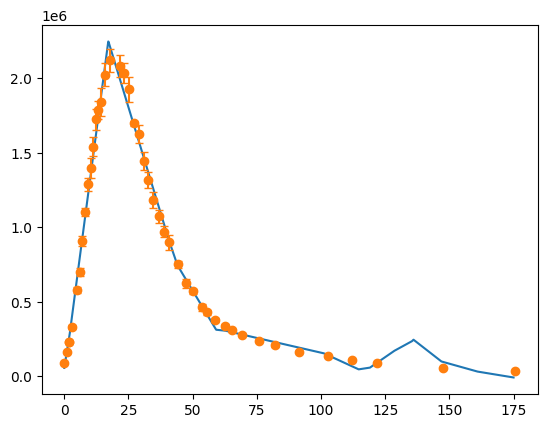

In [19]:
plt.plot(t_grid, flux_pred * np.max(np_flux))
plt.errorbar(np_mjd.flatten(), np_flux.flatten(), yerr=np_flux_err.flatten(), fmt='o', capsize=3)
plt.show()

In [22]:
t_pico = t_grid[np.argmax(flux_pred)]
flux_pico = np.max(flux_pred)

print(f't_pico = {t_pico}')
print(f'flux_pico = {flux_pico * np.max(np_flux)}')

t_pico = [17.13421342]
flux_pico = 2246367.805630778
